# Sweep top-5 ensemble — SHAMe OOD mock (noisy model)

**Noisy** `rand30` sweep (`biasnoisenest` + `noise_unit`) for **$P_{gg}+B+P_{gm}$** with fiducial bispec mask ($k_\text{max}^\text{bispec}=0.25$). Loads the **top N** stall-passing runs from `best_run_log.csv`, then **reads** precomputed SHAMe OOD posteriors from `submit_inf_test.sh` / `run_inference.py` (`samples_test<tag_test>_pred.npy` under each sweep run dir). Plots each posterior plus an **equal-weight mixture** (pooled samples).

**Prerequisite:** run OOD inference jobs first (one per `nth_best_run` 0..N−1), e.g. `generate_config_inference.py` + `submit_inf_test.sh`.

**No inference in this notebook** — missing sample files raise an error.

In [1]:
import csv
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

from choose_best_run import (
    build_sweep_tag_inf,
    sweep_root_for_tag_inf,
    BEST_RUN_LOG_CSV,
)
from generate_config_inference import (
    tags_mask_for_sweep,
    resolve_train_tag_bundle,
    TAG_MASK_BISPEC_SWEEP,
)

%matplotlib inline

2026-06-05 07:28:21.396136: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 07:28:21.492044: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-05 07:28:21.492091: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-05 07:28:21.503954: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-05 07:28:21.531987: I tensorflow/core/platform/cpu_feature_guar

In [13]:
# --- Problem setup: pk + bispec + pgm, noisy rand30 sweep ---
NOISE_MODE = "noisy"
bx = 32
n_train = 10000
N_TOP = 5
# Pool size for equal-weight ensemble (subsampled from loaded files)
N_ENSEMBLE = 1000

data_mode = "muchisimocks"
TAG_SWEEP = "-rand30"
tag_reparam = "_rp"

statistics = ["pk", "bispec", "pgm"]
tags_mask = tags_mask_for_sweep(statistics)

train_bundle = resolve_train_tag_bundle("_p5_n10000", NOISE_MODE)
TAG_PARAMS_TRAIN = train_bundle["tag_params"]
TAG_BIASPARAMS_TRAIN = train_bundle["tag_biasparams"]
TAG_NOISE_TRAIN = train_bundle["tag_noise"]

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"
NBAR_LABEL = "0.00022"

PARAM_NAMES_ZOOM = ["omega_cold", "sigma8_cold", "b1"]
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_mid = extents.copy()
extents_mid["b1"] = [-0.4, 1.4]
extents_narrow = extents.copy()
extents_narrow["b1"] = [0.3, 0.6]
extents_narrow["sigma8_cold"] = [0.7, 0.9]  # fixed-cosmo mean only — too high for SHAMe OOD (~0.68)

# SHAMe OOD posteriors sit below 0.7 in sigma8; use extents_mid (see 2026-04-22 SHAMe notebook).
EXTENTS_CORNER = extents_mid

FIGSIZE_CORNER = (6.5, 6.5)
FONTSIZE_LEGEND = 11
LOC_LEGEND = (1.02, 0.98)
ENSEMBLE_RUN_NAME = f"_ensemble_top5_shame_{NOISE_MODE}"

tag_inf_sweep = build_sweep_tag_inf(
    data_mode=data_mode,
    statistics=statistics,
    tags_mask=tags_mask,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN,
    reparameterize=True,
    tag_sweep=TAG_SWEEP,
)
sweep_root = sweep_root_for_tag_inf(tag_inf_sweep)
dir_sbi_root = paths.DIR_RESULTS / "results_sbi"

tag_stats_train = "_" + "_".join(statistics) + "".join(tags_mask)
tag_test = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=[tag_stats_train],
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)[0]

stat_label = utils_plot.get_stat_label(statistics) + f", {utils_plot.get_mask_label(TAG_MASK_BISPEC_SWEEP)}"
print(f"Sweep tag_inf: {tag_inf_sweep}")
print(f"sweep_root: {sweep_root}")
print(f"SHAMe tag_test: {tag_test}")
print(f"NOISE_MODE: {NOISE_MODE}")
print(f"Statistics: {stat_label}")

Sweep tag_inf: _muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30
sweep_root: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30
SHAMe tag_test: _shame_pk_bispec_pgm_kb0.25_nbar0.00022
NOISE_MODE: noisy
Statistics: $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$, $k_\text{max}^\text{bispec}=0.25$


In [3]:
def load_best_run_log(sweep_root: Path) -> list[dict]:
    log_path = sweep_root / BEST_RUN_LOG_CSV
    if not log_path.is_file():
        raise FileNotFoundError(f"Missing {log_path}")
    rows = []
    with open(log_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            name = (row.get("run_name") or "").strip()
            if not name:
                continue
            loss_s = (row.get("best_val_loss") or "").strip()
            loss = float(loss_s) if loss_s else None
            stall = (row.get("pass_stall_test") or "").strip().lower()
            rows.append({"run_name": name, "best_val_loss": loss, "pass_stall_test": stall})
    rows.sort(key=lambda r: (r["best_val_loss"] is None, r["best_val_loss"] or float("inf")))
    return rows


def top_run_rows(sweep_root: Path, n_top: int, *, require_stall_pass: bool = True) -> list[dict]:
    """Top-N by val loss among runs with pass_stall_test=true (matches choose_best_run intent)."""
    rows = load_best_run_log(sweep_root)
    if not require_stall_pass:
        return rows[:n_top]
    n_false = sum(1 for r in rows if r["pass_stall_test"] == "false")
    n_untested = sum(1 for r in rows if r["pass_stall_test"] not in ("true", "false"))
    passed = [r for r in rows if r["pass_stall_test"] == "true"]
    print(
        f"Stall filter: {len(passed)} passed, {n_false} failed, {n_untested} untested "
        f"(of {len(rows)} in log)"
    )
    return passed[:n_top]


def tag_sbi_run(run_name: str) -> str:
    return f"{tag_inf_sweep}/{run_name}"


def samples_path(tag_sbi: str) -> Path:
    return dir_sbi_root / f"sbi{tag_sbi}" / f"samples_test{tag_test}_pred.npy"


def run_label(row: dict, rank: int) -> str:
    loss = row["best_val_loss"]
    ell = r"$\ell_{\mathrm{val}}$"
    return f"#{rank+1} {row['run_name']}\n{ell}={loss:.3g}"


top_rows = top_run_rows(sweep_root, N_TOP, require_stall_pass=True)
if len(top_rows) < N_TOP:
    raise RuntimeError(
        f"Only {len(top_rows)} stall-passing runs (wanted {N_TOP}). "
        f"Re-run choose_best_run.py with --overwrite to test more runs, or lower N_TOP."
    )

best_id_path = sweep_root / "best_run.txt"
if best_id_path.is_file():
    print(f"best_run.txt -> {best_id_path.read_text().strip()}")

print(f"Top {N_TOP} stall-passing runs (min validation loss):")
for i, row in enumerate(top_rows):
    rd = sweep_root / row["run_name"]
    ok_post = (rd / "posterior.p").is_file()
    print(f"  {i+1}. {row['run_name']:10s}  loss={row['best_val_loss']:.6g}  stall=true  posterior={ok_post}")

Stall filter: 5 passed, 3 failed, 22 untested (of 30 in log)
best_run.txt -> zlf6r7gl
Top 5 stall-passing runs (min validation loss):
  1. zlf6r7gl    loss=-5.94402  stall=true  posterior=True
  2. ng1yr257    loss=-5.86913  stall=true  posterior=True
  3. rjjncomd    loss=-5.65921  stall=true  posterior=True
  4. fvje277c    loss=-4.7319  stall=true  posterior=True
  5. 1ezbfbbs    loss=-4.50516  stall=true  posterior=True


In [4]:
cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_vary,
    bias_param_names_vary=bias_vary,
)
theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_obs_true_show = theta_obs_true[idxs_zoom]

## Load samples (top 5)

Each run: `results_sbi/sbi<tag_inf_sweep>/<run_id>/samples_test<tag_test>_pred.npy` from `run_inference.py`.

In [5]:
def samples_to_matrix(samples: np.ndarray, idx_obs: int = 0) -> np.ndarray:
    """(n_samples, n_params) — same layout as get_samples_sbi for idx_obs."""
    s = np.asarray(samples)
    if s.ndim == 3:
        return s[:, idx_obs, :]
    if s.ndim == 2:
        return s
    raise ValueError(f"Unexpected samples shape {s.shape}")


def load_samples_for_run(run_name: str) -> np.ndarray:
    out = samples_path(tag_sbi_run(run_name))
    if not out.is_file():
        raise FileNotFoundError(
            f"Missing {out}\n"
            f"Run submit_inf_test.sh for this run (nth_best_run matches rank in top_rows)."
        )
    raw = np.load(out)
    samples = samples_to_matrix(raw)
    print(f"  loaded {out}  shape={samples.shape}")
    return samples


samples_by_run = {}
for i, row in enumerate(top_rows):
    rn = row["run_name"]
    print(f"[{i+1}/{N_TOP}] {rn}")
    samples_by_run[rn] = load_samples_for_run(rn)

[1/5] zlf6r7gl
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/zlf6r7gl/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy  shape=(10000, 11)
[2/5] ng1yr257
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/ng1yr257/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy  shape=(10000, 11)
[3/5] rjjncomd
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/rjjncomd/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy  shape=(10000, 11)
[4/5] fvje277c
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_bias

In [6]:
def mixture_sample_equal(rng: np.random.Generator, sample_dict: dict, n_total: int) -> np.ndarray:
    """Equal-weight mixture: n_total draws, each from a uniformly chosen run."""
    names = list(sample_dict.keys())
    n_per = n_total // len(names)
    remainder = n_total - n_per * len(names)
    chunks = []
    for j, name in enumerate(names):
        n_j = n_per + (1 if j < remainder else 0)
        s = samples_to_matrix(sample_dict[name])
        idx = rng.choice(s.shape[0], size=n_j, replace=(n_j > s.shape[0]))
        chunks.append(s[idx])
    out = np.vstack(chunks)
    rng.shuffle(out, axis=0)
    return out


rng = np.random.default_rng(42)
samples_ensemble = mixture_sample_equal(rng, samples_by_run, N_ENSEMBLE)
print(f"Ensemble mixture: {samples_ensemble.shape[0]} draws from {len(samples_by_run)} runs")

# Save mixture for plot_contours_inf (loads from disk; no inference)
tag_sbi_ensemble = f"{tag_inf_sweep}/{ENSEMBLE_RUN_NAME}"
ensemble_dir = dir_sbi_root / f"sbi{tag_sbi_ensemble}"
ensemble_dir.mkdir(parents=True, exist_ok=True)
src_pn = sweep_root / top_rows[0]["run_name"] / "param_names.txt"
dst_pn = ensemble_dir / "param_names.txt"
if not dst_pn.exists():
    dst_pn.write_bytes(src_pn.read_bytes())
ensemble_out = samples_path(tag_sbi_ensemble)
np.save(ensemble_out, samples_ensemble)
print(f"Ensemble saved for plotting: {ensemble_out}")

Ensemble mixture: 1000 draws from 5 runs
Ensemble saved for plotting: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/_ensemble_top5_shame_noisy/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


## Consistency summary

In [7]:
def zoom_mean_std(samples: np.ndarray, pn_chain: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """Posterior mean/std in physical params (unreparameterize chain names first)."""
    s = samples_to_matrix(samples)
    su, names_u = utils_inference.unreparameterize_theta(s, list(pn_chain), strict=False)
    names_u = list(names_u)
    idx_show = [names_u.index(p) for p in PARAM_NAMES_ZOOM]
    block = su[:, idx_show]
    return block.mean(axis=0), block.std(axis=0)


pn_chain = list(np.loadtxt(sweep_root / top_rows[0]["run_name"] / "param_names.txt", dtype=str))

rows_summary = []
for row in top_rows:
    m, sd = zoom_mean_std(samples_by_run[row["run_name"]], pn_chain)
    rows_summary.append((row["run_name"], m, sd))

m_e, sd_e = zoom_mean_std(samples_ensemble, pn_chain)
rows_summary.append(("ensemble", m_e, sd_e))

hdr = "run".ljust(12) + "".join(f"{p:>18s}" for p in PARAM_NAMES_ZOOM)
print(hdr)
print("means")
for name, m, _ in rows_summary:
    print(name.ljust(12) + "".join(f"{v:18.4f}" for v in m))
print("stds")
for name, _, sd in rows_summary:
    print(name.ljust(12) + "".join(f"{v:18.4f}" for v in sd))

spread = np.std([m for _, m, _ in rows_summary[:-1]], axis=0)
print("\nSpread of top-5 posterior means (per param):", dict(zip(PARAM_NAMES_ZOOM, spread)))

run                 omega_cold       sigma8_cold                b1
means
zlf6r7gl                0.3070            0.7889            0.4768
ng1yr257                0.3058            0.7915            0.4662
rjjncomd                0.3135            0.7891            0.4759
fvje277c                0.3129            0.7900            0.4649
1ezbfbbs                0.3082            0.7899            0.4692
ensemble                0.3100            0.7897            0.4707
stds
zlf6r7gl                0.0139            0.0084            0.0141
ng1yr257                0.0140            0.0098            0.0206
rjjncomd                0.0149            0.0091            0.0158
fvje277c                0.0142            0.0096            0.0185
1ezbfbbs                0.0136            0.0097            0.0189
ensemble                0.0143            0.0095            0.0179

Spread of top-5 posterior means (per param): {'omega_cold': 0.0031371074207706883, 'sigma8_cold': 0.00094491084172430

## Diagnostics

Check loaded sample counts, physical posterior ranges vs axis limits, and truth.

## Corner plots

Uses `EXTENTS_CORNER` (= `extents_mid`). Re-submit `submit_inf_test.sh` if a run is missing `samples_test<tag_test>_pred.npy`.

In [8]:
def print_posterior_diagnostics(run_name: str, samples: np.ndarray, pn_chain: list[str]) -> None:
    s = samples_to_matrix(samples)
    su, names_u = utils_inference.unreparameterize_theta(s, pn_chain, strict=False)
    names_u = list(names_u)
    print(f"--- {run_name}  n_samples={s.shape[0]} ---")
    for pn in PARAM_NAMES_ZOOM:
        if pn not in names_u:
            print(f"  {pn}: MISSING from chain")
            continue
        col = su[:, names_u.index(pn)]
        lo, hi = EXTENTS_CORNER.get(pn, extents.get(pn, (None, None)))
        q = np.percentile(col, [5, 50, 95])
        in_range = (lo is None or q[0] >= lo) and (hi is None or q[2] <= hi)
        flag = "" if in_range else "  ** OUTSIDE EXTENTS_CORNER **"
        print(
            f"  {pn:14s}  q05={q[0]:.4f}  q50={q[1]:.4f}  q95={q[2]:.4f}  "
            f"extent=[{lo}, {hi}]{flag}"
        )
    if theta_obs_true_show is not None:
        print("  truth (zoom):", dict(zip(PARAM_NAMES_ZOOM, theta_obs_true_show)))


pn_chain = list(np.loadtxt(sweep_root / top_rows[0]["run_name"] / "param_names.txt", dtype=str))
for row in top_rows:
    print_posterior_diagnostics(row["run_name"], samples_by_run[row["run_name"]], pn_chain)
print(f"\nPlot axes: EXTENTS_CORNER (not extents_narrow — narrow sigma8 cuts off SHAMe OOD ~0.68)")

--- zlf6r7gl  n_samples=10000 ---
  omega_cold      q05=0.2842  q50=0.3070  q95=0.3299  extent=[0.23, 0.4]
  sigma8_cold     q05=0.7750  q50=0.7889  q95=0.8027  extent=[0.65, 0.9]
  b1              q05=0.4526  q50=0.4773  q95=0.4991  extent=[-0.4, 1.4]
  truth (zoom): {'omega_cold': 0.30889999999999995, 'sigma8_cold': 0.8159000277519226, 'b1': 0.47410742}
--- ng1yr257  n_samples=10000 ---
  omega_cold      q05=0.2827  q50=0.3058  q95=0.3289  extent=[0.23, 0.4]
  sigma8_cold     q05=0.7758  q50=0.7913  q95=0.8079  extent=[0.65, 0.9]
  b1              q05=0.4306  q50=0.4676  q95=0.4977  extent=[-0.4, 1.4]
  truth (zoom): {'omega_cold': 0.30889999999999995, 'sigma8_cold': 0.8159000277519226, 'b1': 0.47410742}
--- rjjncomd  n_samples=10000 ---
  omega_cold      q05=0.2888  q50=0.3133  q95=0.3377  extent=[0.23, 0.4]
  sigma8_cold     q05=0.7742  q50=0.7890  q95=0.8040  extent=[0.65, 0.9]
  b1              q05=0.4494  q50=0.4762  q95=0.5005  extent=[-0.4, 1.4]
  truth (zoom): {'omega_cold': 

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/zlf6r7gl/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/ng1yr257/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/rjjncomd/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/fvje277c/samples_test_sham

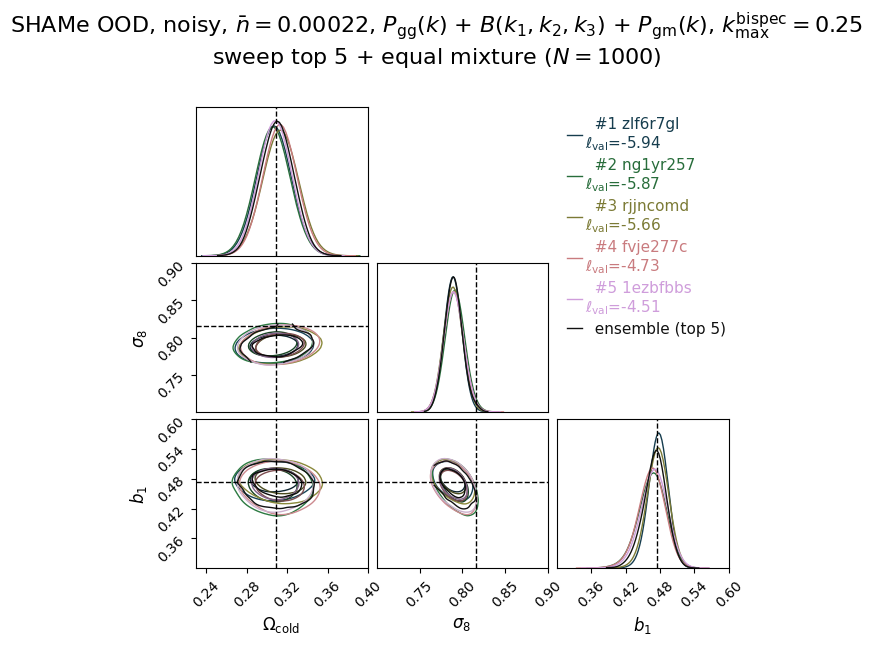

In [23]:
def pp_colors(n):
    return [
        mcolors.to_hex(c)
        for c in plt.cm.cubehelix(np.linspace(0.2, 0.7, max(n, 1)))
    ]


tags_inf_top = [tag_sbi_run(r["run_name"]) for r in top_rows]
labels_top = [run_label(r, i) for i, r in enumerate(top_rows)]
colors_top = pp_colors(N_TOP)

title_overlay = (
    f"SHAMe OOD, {NOISE_MODE}, $\\bar n={NBAR_LABEL}$, {stat_label}\n"
    f"sweep top {N_TOP} + equal mixture ($N={N_ENSEMBLE}$)"
)

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=["sbi"] * (N_TOP + 1),
    tags_inf=tags_inf_top + [tag_sbi_ensemble],
    tags_test=[tag_test] * (N_TOP + 1),
    colors=colors_top + ["#111111"],
    labels=labels_top + [f"ensemble (top {N_TOP})"],
    title=title_overlay,
    extents=extents_narrow,
    figsize=FIGSIZE_CORNER,
    fontsize_legend=FONTSIZE_LEGEND,
    loc_legend=LOC_LEGEND,
    unreparameterize=True,
)
plt.show()